In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import json

In [42]:
best_thresholds = pd.read_excel('../Results/Vogl_Workflow_Results_Best.xlsx', sheet_name='Sheet1')
best_thresholds['auc'] = best_thresholds['auc'].apply(json.loads)

best_selected = pd.read_excel('../Results/Vogl_Workflow_Results_Best.xlsx', sheet_name='Selected_bootstrap')
best_selected['auc'] = best_selected['auc'].apply(json.loads)

grouped_clinical = pd.read_csv('../Results/grouped_clinical.csv', index_col=0)


auc_mean  ci95_low  \
auc                                                                      
[0.7001262626262625, 0.4437340153452686, 0.5680...  0.466338  0.347553   

                                                    ci95_high       std  
auc                                                                      
[0.7001262626262625, 0.4437340153452686, 0.5680...   0.608397  0.066575

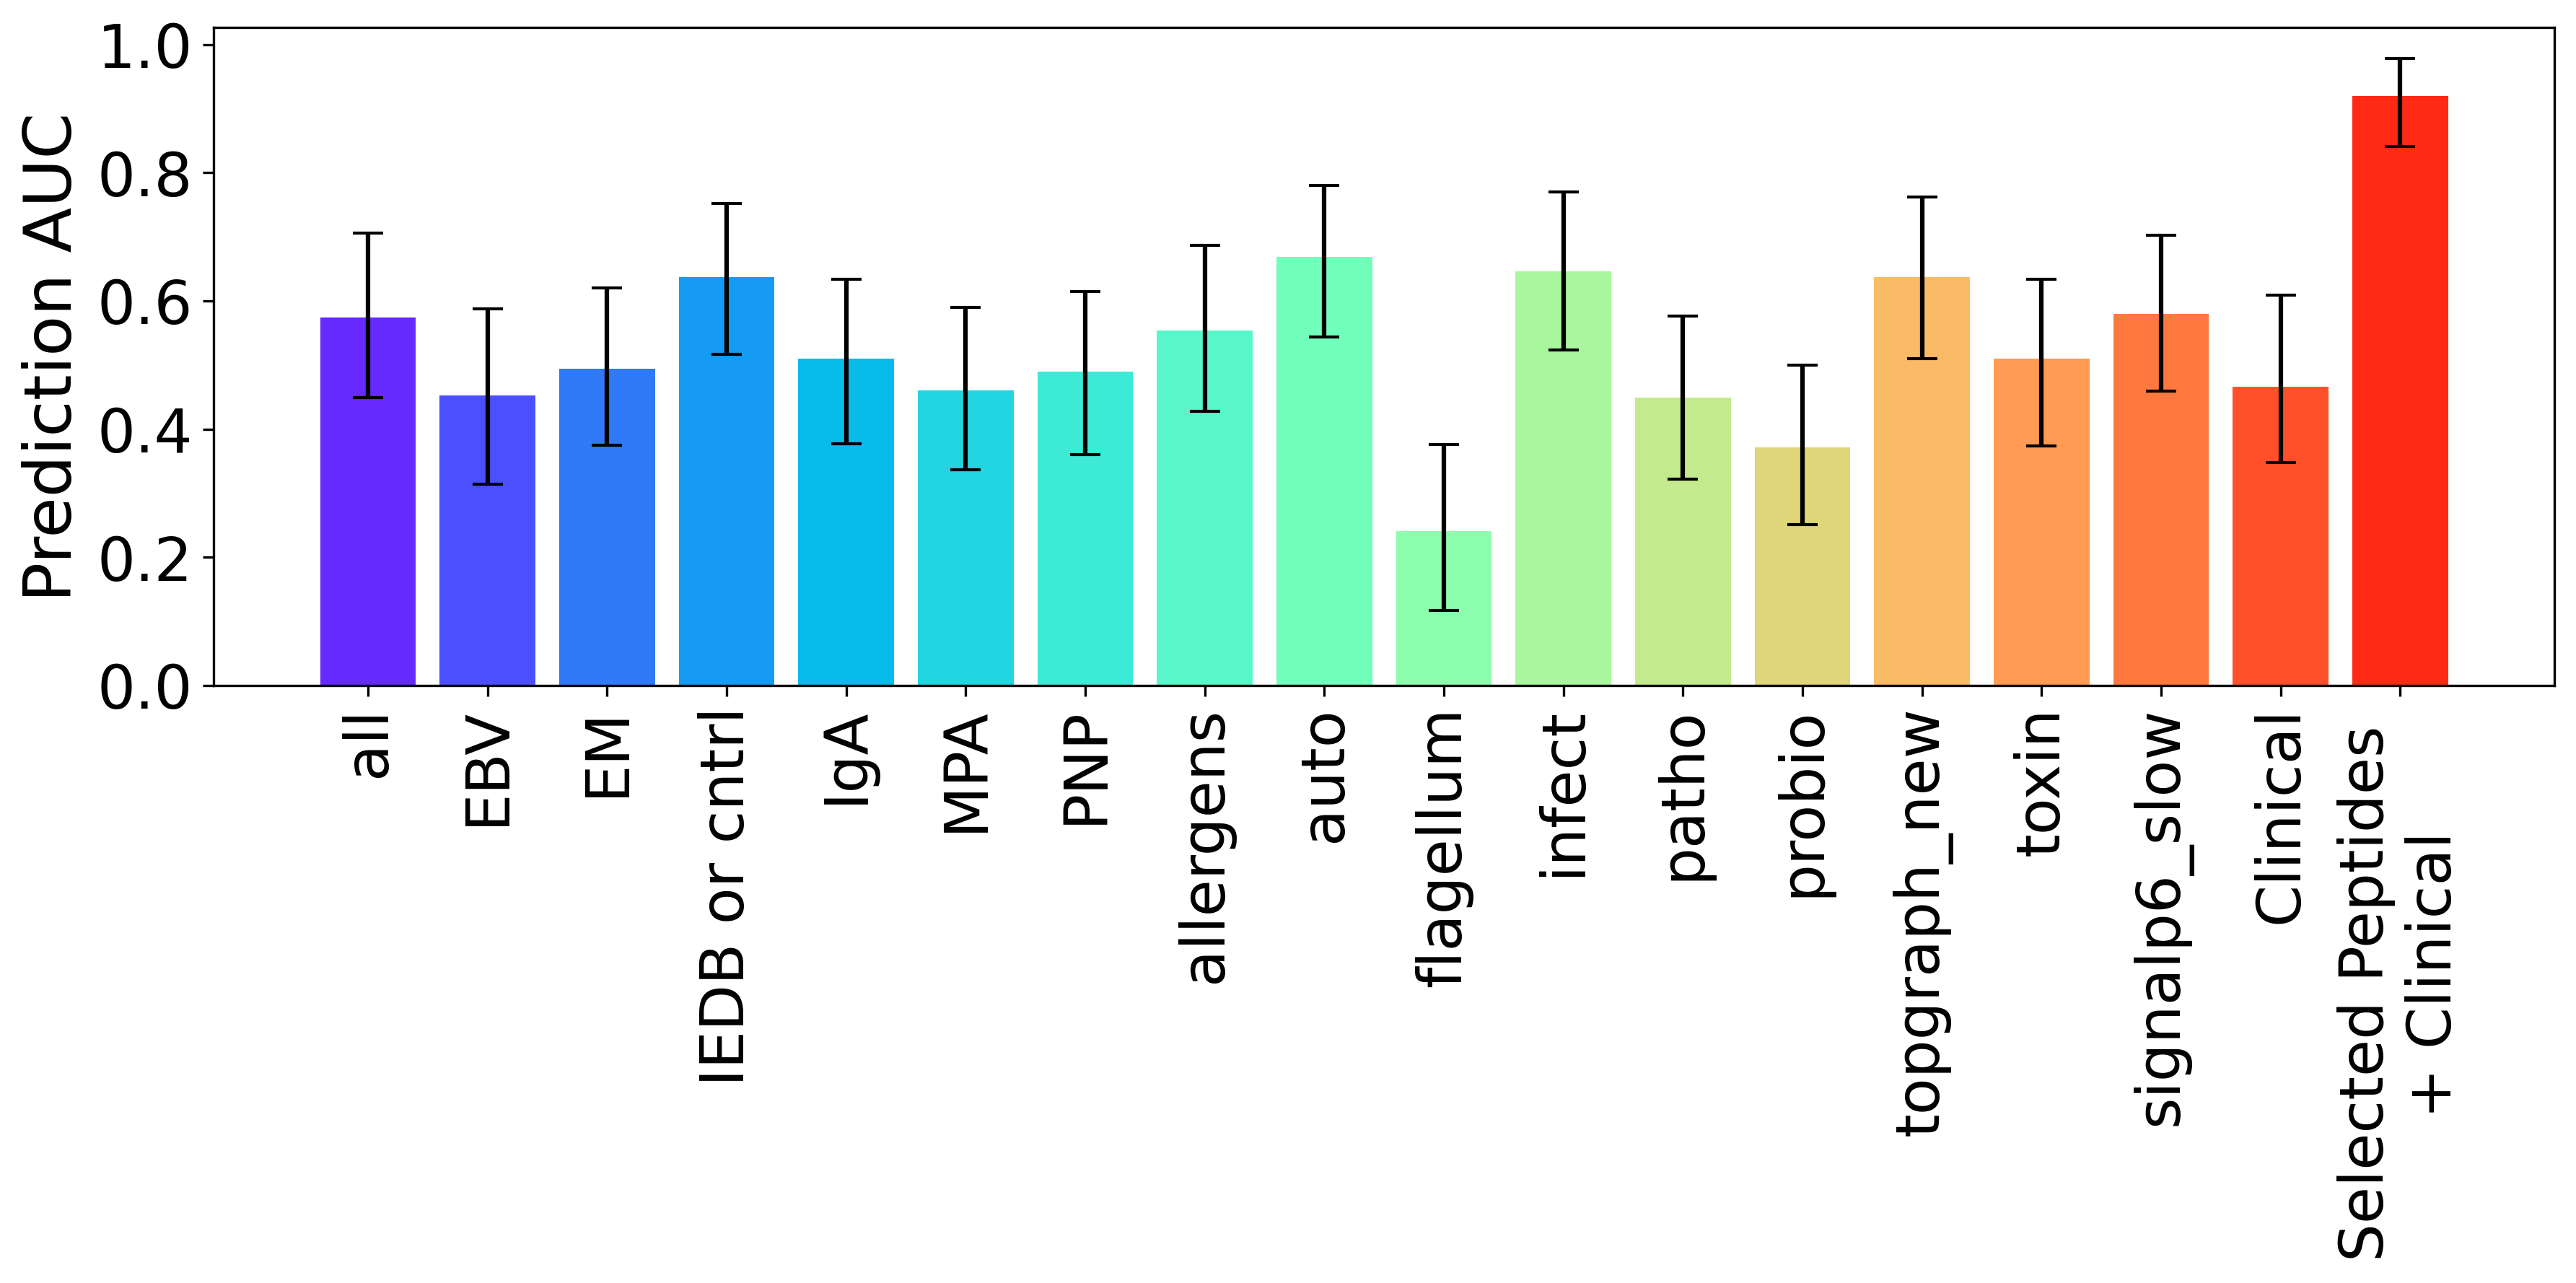

In [69]:
# Número de subgrupos para la paleta
n = len(best_thresholds) + 2

# Cálculo de las barras del IC
auc_means = np.append(best_thresholds['auc_mean'], grouped_clinical['auc_mean'])
auc_means = np.append(auc_means, best_selected['auc_mean'])

ci95_low = np.append(best_thresholds['ci95_low'], grouped_clinical['ci95_low'])
ci95_low = np.append(ci95_low, best_selected['ci95_low'])

ci95_high = np.append(best_thresholds['ci95_high'], grouped_clinical['ci95_high'])
ci95_high = np.append(ci95_high, best_selected['ci95_high'])

yerr = np.array([
    auc_means - ci95_low,
    ci95_high - auc_means
])

x_labels = list(best_thresholds['subgroup']) + ['Clinical'] + ['Selected Peptides \n + Clinical']
x_labels = [label.replace('is_', '') for label in x_labels]
x_labels = [label.replace('_or_', ' or ') for label in x_labels]
plt.figure(figsize=(12, 6), dpi=300)

bars = plt.bar(
    x_labels,
    auc_means,
    yerr=yerr,
    capsize=5,
    color=sns.color_palette("rainbow", n_colors=n),
)
titlesize = 22
ticksize = 20
labelsize = 22
plt.ylabel('Prediction AUC', fontsize=labelsize)
plt.xticks(rotation=90, fontsize=ticksize)
plt.yticks(fontsize=ticksize)
plt.tight_layout()

plt.savefig('../Figures/AUC_Barplot.svg', transparent=True,
            bbox_inches='tight')